In [1]:
import subprocess
import time
import json
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Diccionario para almacenar los tiempos de ejecución
execution_times = {
    'SST': {},
    'CFIMDB': {}
}

In [2]:
import subprocess
result = subprocess.run(["python", "sanity_check.py"], capture_output=True, text=True)
print(result.stdout)  # muestra lo que imprime el script



Your Llama implementation is correct!



In [3]:
result = subprocess.run(["python", "optimizer_test.py"], capture_output=True, text=True)
print(result.stdout)  # muestra lo que imprime el script

Optimizer test passed!



In [4]:
### python rope_test.py
result = subprocess.run(["python", "rope_test.py"], capture_output=True, text=True)
print(result.stdout)  # muestra lo que imprime el script

Rotary embedding test passed!



In [5]:
### python run_llama.py --option generate
result = subprocess.run(
    [
        "python",
        "run_llama.py",
        "--option",
        "generate",
    ],
    capture_output=True,
    text=True,
)
print(result.stdout)  # muestra lo que imprime el script

args: {'train': 'data/cfimdb-train.txt', 'dev': 'data/cfimdb-dev.txt', 'test': 'data/cfimdb-test.txt', 'label_names': 'data/cfimdb-label-mapping.json', 'pretrained_model_path': 'stories42M.pt', 'max_sentence_len': None, 'seed': 1337, 'epochs': 5, 'option': 'generate', 'use_gpu': False, 'generated_sentence_low_temp_out': 'generated-sentence-temp-0.txt', 'generated_sentence_high_temp_out': 'generated-sentence-temp-1.txt', 'dev_out': 'cfimdb-dev-prompting-output.txt', 'test_out': 'cfimdb-test-prompting-output.txt', 'lora_rank': 4, 'lora_alpha': 1.0, 'batch_size': 8, 'hidden_dropout_prob': 0.3, 'lr': 2e-05}
load model from stories42M.pt
Temperature is 0.0
I have wanted to see this thriller for a while, and it didn't disappoint. Keanu Reeves, playing the hero John Wick, is this day. He was playing with his toy car, driving it around the living room. Suddenly, he heard a loud crash. He had broken the car and was very sad. He knew he had done something wrong. He had to be punished. He had to 

In [6]:
## Complete SST zero-shot prompting
start_time = time.time()
result = subprocess.run(
    ["python", "run_llama.py",
     "--option", "prompt",
        "--batch_size", "10",
        "--train", "data/sst-train.txt",
        "--dev", "data/sst-dev.txt",
        "--test", "data/sst-test.txt",
        "--label-names", "data/sst-label-mapping.json",
        "--dev_out", "sst-dev-prompting-output.txt",
        "--test_out", "sst-test-prompting-output.txt",
        "--use_gpu"
    ],
    capture_output=True,
    text=True,
)
end_time = time.time()
execution_times['SST']['prompting'] = end_time - start_time
print(f"SST Prompting time: {execution_times['SST']['prompting']:.2f} seconds")
print(result.stdout)  # muestra lo que imprime el script

SST Prompting time: 11.03 seconds
args: {'train': 'data/sst-train.txt', 'dev': 'data/sst-dev.txt', 'test': 'data/sst-test.txt', 'label_names': 'data/sst-label-mapping.json', 'pretrained_model_path': 'stories42M.pt', 'max_sentence_len': None, 'seed': 1337, 'epochs': 5, 'option': 'prompt', 'use_gpu': True, 'generated_sentence_low_temp_out': 'generated-sentence-temp-0.txt', 'generated_sentence_high_temp_out': 'generated-sentence-temp-1.txt', 'dev_out': 'sst-dev-prompting-output.txt', 'test_out': 'sst-test-prompting-output.txt', 'lora_rank': 4, 'lora_alpha': 1.0, 'batch_size': 10, 'hidden_dropout_prob': 0.3, 'lr': 2e-05}
load 8544 data from data/sst-train.txt
load 1101 data from data/sst-dev.txt
load 2210 data from data/sst-test.txt
dev acc :: 0.235
test acc :: 0.248



In [7]:
## Complete CFIMDB zero-shot prompting
start_time = time.time()
result = subprocess.run(
    ["python", "run_llama.py",
        "--option", "prompt",
        "--batch_size", "10",
        "--train", "data/cfimdb-train.txt",
        "--dev", "data/cfimdb-dev.txt",
        "--test", "data/cfimdb-test.txt",
        "--label-names", "data/cfimdb-label-mapping.json",
        "--dev_out", "cfimdb-dev-prompting-output.txt",
        "--test_out", "cfimdb-test-prompting-output.txt",
        "--use_gpu"
    ],
    capture_output=True,
    text=True,
)
end_time = time.time()
execution_times['CFIMDB']['prompting'] = end_time - start_time
print(f"CFIMDB Prompting time: {execution_times['CFIMDB']['prompting']:.2f} seconds")
print(result.stdout)  # muestra lo que imprime el script

CFIMDB Prompting time: 7.55 seconds
args: {'train': 'data/cfimdb-train.txt', 'dev': 'data/cfimdb-dev.txt', 'test': 'data/cfimdb-test.txt', 'label_names': 'data/cfimdb-label-mapping.json', 'pretrained_model_path': 'stories42M.pt', 'max_sentence_len': None, 'seed': 1337, 'epochs': 5, 'option': 'prompt', 'use_gpu': True, 'generated_sentence_low_temp_out': 'generated-sentence-temp-0.txt', 'generated_sentence_high_temp_out': 'generated-sentence-temp-1.txt', 'dev_out': 'cfimdb-dev-prompting-output.txt', 'test_out': 'cfimdb-test-prompting-output.txt', 'lora_rank': 4, 'lora_alpha': 1.0, 'batch_size': 10, 'hidden_dropout_prob': 0.3, 'lr': 2e-05}
load 1707 data from data/cfimdb-train.txt
load 245 data from data/cfimdb-dev.txt
load 488 data from data/cfimdb-test.txt
dev acc :: 0.490
test acc :: 0.109



In [8]:
### Complete SST fine-tuning
start_time = time.time()
result = subprocess.run(
    ["python", "run_llama.py",
        "--option", "finetune",
        "--epochs", "5",
        "--lr", "2e-5",
        "--batch_size", "80",
        "--train", "data/sst-train.txt",
        "--dev", "data/sst-dev.txt",
        "--test", "data/sst-test.txt",
        "--label-names", "data/sst-label-mapping.json",
        "--dev_out", "sst-dev-finetuning-output.txt",
        "--test_out", "sst-test-finetuning-output.txt",
        "--use_gpu"
    ],
    capture_output=True,
    text=True,
)
end_time = time.time()
execution_times['SST']['finetuning'] = end_time - start_time
print(f"SST Fine-tuning time: {execution_times['SST']['finetuning']:.2f} seconds")
print(result.stdout)  # muestra lo que imprime el script

SST Fine-tuning time: 72.22 seconds
args: {'train': 'data/sst-train.txt', 'dev': 'data/sst-dev.txt', 'test': 'data/sst-test.txt', 'label_names': 'data/sst-label-mapping.json', 'pretrained_model_path': 'stories42M.pt', 'max_sentence_len': None, 'seed': 1337, 'epochs': 5, 'option': 'finetune', 'use_gpu': True, 'generated_sentence_low_temp_out': 'generated-sentence-temp-0.txt', 'generated_sentence_high_temp_out': 'generated-sentence-temp-1.txt', 'dev_out': 'sst-dev-finetuning-output.txt', 'test_out': 'sst-test-finetuning-output.txt', 'lora_rank': 4, 'lora_alpha': 1.0, 'batch_size': 80, 'hidden_dropout_prob': 0.3, 'lr': 2e-05}
load 8544 data from data/sst-train.txt
load 1101 data from data/sst-dev.txt
save the model to finetune-5-2e-05.pt
epoch 0: train loss :: 1.891, train acc :: 0.263, dev acc :: 0.265
save the model to finetune-5-2e-05.pt
epoch 1: train loss :: 1.646, train acc :: 0.301, dev acc :: 0.293
save the model to finetune-5-2e-05.pt
epoch 2: train loss :: 1.502, train acc :: 0.

In [9]:
### Complete CFIMDB fine-tuning
start_time = time.time()
result = subprocess.run(
    ["python", "run_llama.py",
        "--option", "finetune",
        "--epochs", "5",
        "--lr", "2e-5",
        "--batch_size", "10",
        "--train", "data/cfimdb-train.txt",
        "--dev", "data/cfimdb-dev.txt",
        "--test", "data/cfimdb-test.txt",
        "--label-names", "data/cfimdb-label-mapping.json",
        "--dev_out", "cfimdb-dev-finetuning-output.txt",
        "--test_out", "cfimdb-test-finetuning-output.txt",
        "--use_gpu"
    ],
    capture_output=True,
    text=True,
)
end_time = time.time()
execution_times['CFIMDB']['finetuning'] = end_time - start_time
print(f"CFIMDB Fine-tuning time: {execution_times['CFIMDB']['finetuning']:.2f} seconds")
print(result.stdout)  # muestra lo que imprime el script

CFIMDB Fine-tuning time: 114.47 seconds
args: {'train': 'data/cfimdb-train.txt', 'dev': 'data/cfimdb-dev.txt', 'test': 'data/cfimdb-test.txt', 'label_names': 'data/cfimdb-label-mapping.json', 'pretrained_model_path': 'stories42M.pt', 'max_sentence_len': None, 'seed': 1337, 'epochs': 5, 'option': 'finetune', 'use_gpu': True, 'generated_sentence_low_temp_out': 'generated-sentence-temp-0.txt', 'generated_sentence_high_temp_out': 'generated-sentence-temp-1.txt', 'dev_out': 'cfimdb-dev-finetuning-output.txt', 'test_out': 'cfimdb-test-finetuning-output.txt', 'lora_rank': 4, 'lora_alpha': 1.0, 'batch_size': 10, 'hidden_dropout_prob': 0.3, 'lr': 2e-05}
load 1707 data from data/cfimdb-train.txt
load 245 data from data/cfimdb-dev.txt
save the model to finetune-5-2e-05.pt
epoch 0: train loss :: 0.976, train acc :: 0.501, dev acc :: 0.502
epoch 1: train loss :: 0.818, train acc :: 0.503, dev acc :: 0.502
save the model to finetune-5-2e-05.pt
epoch 2: train loss :: 0.745, train acc :: 0.531, dev ac

In [10]:
## Complete SST LoRA fine-tuning
start_time = time.time()
result = subprocess.run(
    ["python", "run_llama.py",
        "--option", "lora",
        "--epochs", "5",
        "--lr", "2e-5",
        "--batch_size", "80",
        "--train", "data/sst-train.txt",
        "--dev", "data/sst-dev.txt",
        "--test", "data/sst-test.txt",
        "--label-names", "data/sst-label-mapping.json",
        "--dev_out", "sst-dev-lora-output.txt",
        "--test_out", "sst-test-lora-output.txt",
        "--lora_rank", "4",
        "--lora_alpha", "1.0",
        "--use_gpu"
    ],
    capture_output=True,
    text=True,
)
end_time = time.time()
execution_times['SST']['lora'] = end_time - start_time
print(f"SST LoRA time: {execution_times['SST']['lora']:.2f} seconds")
print(result.stdout)  # muestra lo que imprime el script

SST LoRA time: 71.99 seconds
args: {'train': 'data/sst-train.txt', 'dev': 'data/sst-dev.txt', 'test': 'data/sst-test.txt', 'label_names': 'data/sst-label-mapping.json', 'pretrained_model_path': 'stories42M.pt', 'max_sentence_len': None, 'seed': 1337, 'epochs': 5, 'option': 'lora', 'use_gpu': True, 'generated_sentence_low_temp_out': 'generated-sentence-temp-0.txt', 'generated_sentence_high_temp_out': 'generated-sentence-temp-1.txt', 'dev_out': 'sst-dev-lora-output.txt', 'test_out': 'sst-test-lora-output.txt', 'lora_rank': 4, 'lora_alpha': 1.0, 'batch_size': 80, 'hidden_dropout_prob': 0.3, 'lr': 2e-05}
load 8544 data from data/sst-train.txt
load 1101 data from data/sst-dev.txt
Applying LoRA with rank=4, alpha=1.0
LoRA aplicado a layers.0.attention.compute_query
LoRA aplicado a layers.0.attention.compute_key
LoRA aplicado a layers.0.attention.compute_value
LoRA aplicado a layers.0.attention.compute_output
LoRA aplicado a layers.1.attention.compute_query
LoRA aplicado a layers.1.attention.

In [11]:
## Complete CFIMDB LoRA fine-tuning
start_time = time.time()
result = subprocess.run(
    ["python", "run_llama.py",
        "--option", "lora",
        "--epochs", "5",
        "--lr", "2e-5",
        "--batch_size", "10",
        "--train", "data/cfimdb-train.txt",
        "--dev", "data/cfimdb-dev.txt",
        "--test", "data/cfimdb-test.txt",
        "--label-names", "data/cfimdb-label-mapping.json",
        "--dev_out", "cfimdb-dev-lora-output.txt",
        "--test_out", "cfimdb-test-lora-output.txt",    
        "--lora_rank", "4",
        "--lora_alpha", "1.0",
        "--use_gpu"
    ],  
    capture_output=True,
    text=True,
)
end_time = time.time()
execution_times['CFIMDB']['lora'] = end_time - start_time
print(f"CFIMDB LoRA time: {execution_times['CFIMDB']['lora']:.2f} seconds")
print(result.stdout)  # muestra lo que imprime el script

CFIMDB LoRA time: 111.75 seconds
args: {'train': 'data/cfimdb-train.txt', 'dev': 'data/cfimdb-dev.txt', 'test': 'data/cfimdb-test.txt', 'label_names': 'data/cfimdb-label-mapping.json', 'pretrained_model_path': 'stories42M.pt', 'max_sentence_len': None, 'seed': 1337, 'epochs': 5, 'option': 'lora', 'use_gpu': True, 'generated_sentence_low_temp_out': 'generated-sentence-temp-0.txt', 'generated_sentence_high_temp_out': 'generated-sentence-temp-1.txt', 'dev_out': 'cfimdb-dev-lora-output.txt', 'test_out': 'cfimdb-test-lora-output.txt', 'lora_rank': 4, 'lora_alpha': 1.0, 'batch_size': 10, 'hidden_dropout_prob': 0.3, 'lr': 2e-05}
load 1707 data from data/cfimdb-train.txt
load 245 data from data/cfimdb-dev.txt
Applying LoRA with rank=4, alpha=1.0
LoRA aplicado a layers.0.attention.compute_query
LoRA aplicado a layers.0.attention.compute_key
LoRA aplicado a layers.0.attention.compute_value
LoRA aplicado a layers.0.attention.compute_output
LoRA aplicado a layers.1.attention.compute_query
LoRA apl

In [12]:
# Guardar tiempos de ejecución en un archivo JSON
with open('execution_times.json', 'w') as f:
    json.dump(execution_times, f, indent=2)

print("Tiempos de ejecución guardados en 'execution_times.json'")
print("\nResumen de tiempos:")
for dataset in execution_times:
    print(f"\n{dataset}:")
    for method, time_taken in execution_times[dataset].items():
        print(f"  {method}: {time_taken:.2f} segundos")

Tiempos de ejecución guardados en 'execution_times.json'

Resumen de tiempos:

SST:
  prompting: 11.03 segundos
  finetuning: 72.22 segundos
  lora: 71.99 segundos

CFIMDB:
  prompting: 7.55 segundos
  finetuning: 114.47 segundos
  lora: 111.75 segundos


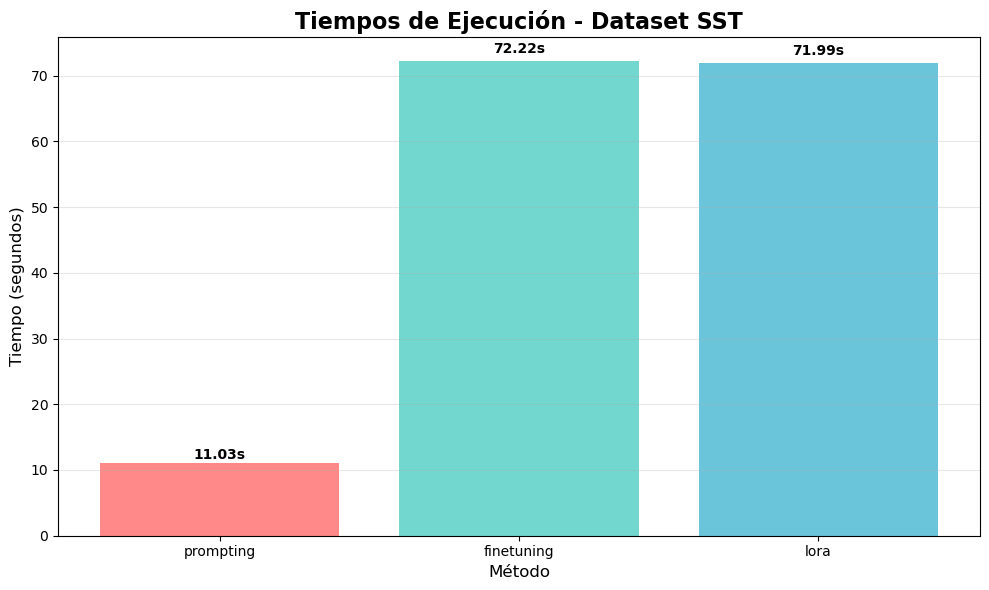

Tiempo promedio SST: 51.75 segundos


In [13]:
# Crear gráfico de barras para SST dataset
methods = list(execution_times['SST'].keys())
times_sst = list(execution_times['SST'].values())

plt.figure(figsize=(10, 6))
bars_sst = plt.bar(methods, times_sst, color=['#FF6B6B', '#4ECDC4', '#45B7D1'], alpha=0.8)
plt.title('Tiempos de Ejecución - Dataset SST', fontsize=16, fontweight='bold')
plt.xlabel('Método', fontsize=12)
plt.ylabel('Tiempo (segundos)', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')

# Agregar valores en las barras
for bar, time_val in zip(bars_sst, times_sst):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
             f'{time_val:.2f}s', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Tiempo promedio SST: {np.mean(times_sst):.2f} segundos")

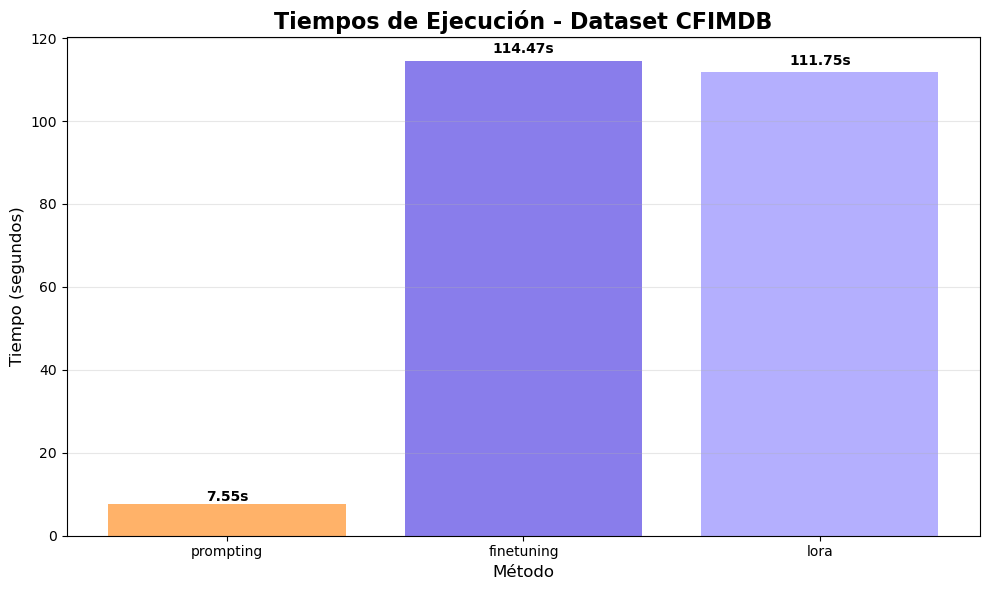

Tiempo promedio CFIMDB: 77.92 segundos


In [14]:
# Crear gráfico de barras para CFIMDB dataset
methods = list(execution_times['CFIMDB'].keys())
times_cfimdb = list(execution_times['CFIMDB'].values())

plt.figure(figsize=(10, 6))
bars_cfimdb = plt.bar(methods, times_cfimdb, color=['#FF9F43', '#6C5CE7', '#A29BFE'], alpha=0.8)
plt.title('Tiempos de Ejecución - Dataset CFIMDB', fontsize=16, fontweight='bold')
plt.xlabel('Método', fontsize=12)
plt.ylabel('Tiempo (segundos)', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')

# Agregar valores en las barras
for bar, time_val in zip(bars_cfimdb, times_cfimdb):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
             f'{time_val:.2f}s', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Tiempo promedio CFIMDB: {np.mean(times_cfimdb):.2f} segundos")

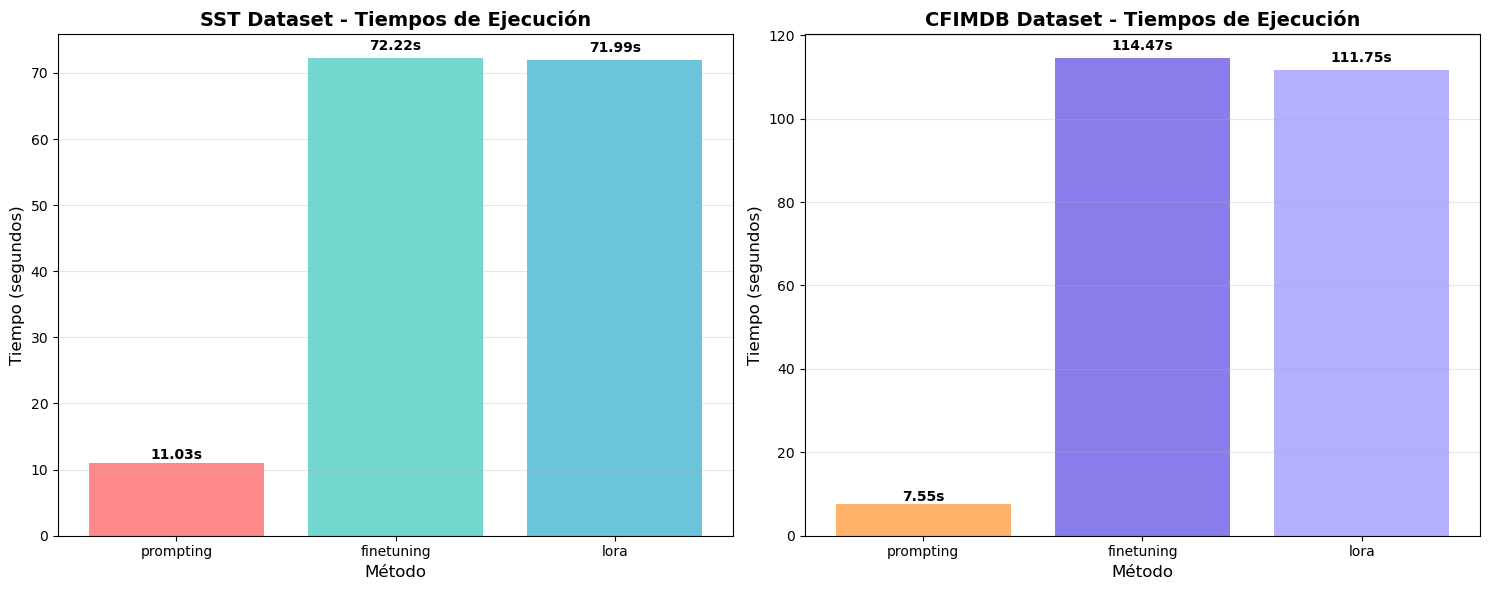

=== RESUMEN ESTADÍSTICO ===
SST - Promedio: 51.75s, Mín: 11.03s, Máx: 72.22s
CFIMDB - Promedio: 77.92s, Mín: 7.55s, Máx: 114.47s


In [15]:
# Gráfico comparativo de ambos datasets
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# SST Dataset
methods_sst = list(execution_times['SST'].keys())
times_sst = list(execution_times['SST'].values())
bars1 = ax1.bar(methods_sst, times_sst, color=['#FF6B6B', '#4ECDC4', '#45B7D1'], alpha=0.8)
ax1.set_title('SST Dataset - Tiempos de Ejecución', fontsize=14, fontweight='bold')
ax1.set_xlabel('Método', fontsize=12)
ax1.set_ylabel('Tiempo (segundos)', fontsize=12)
ax1.grid(True, alpha=0.3, axis='y')

# Agregar valores en las barras SST
for bar, time_val in zip(bars1, times_sst):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
             f'{time_val:.2f}s', ha='center', va='bottom', fontweight='bold')

# CFIMDB Dataset
methods_cfimdb = list(execution_times['CFIMDB'].keys())
times_cfimdb = list(execution_times['CFIMDB'].values())
bars2 = ax2.bar(methods_cfimdb, times_cfimdb, color=['#FF9F43', '#6C5CE7', '#A29BFE'], alpha=0.8)
ax2.set_title('CFIMDB Dataset - Tiempos de Ejecución', fontsize=14, fontweight='bold')
ax2.set_xlabel('Método', fontsize=12)
ax2.set_ylabel('Tiempo (segundos)', fontsize=12)
ax2.grid(True, alpha=0.3, axis='y')

# Agregar valores en las barras CFIMDB
for bar, time_val in zip(bars2, times_cfimdb):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
             f'{time_val:.2f}s', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Resumen estadístico
print("=== RESUMEN ESTADÍSTICO ===")
print(f"SST - Promedio: {np.mean(times_sst):.2f}s, Mín: {np.min(times_sst):.2f}s, Máx: {np.max(times_sst):.2f}s")
print(f"CFIMDB - Promedio: {np.mean(times_cfimdb):.2f}s, Mín: {np.min(times_cfimdb):.2f}s, Máx: {np.max(times_cfimdb):.2f}s")